In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import GroupShuffleSplit
import xgboost as xgb
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_squared_error
from sklearn.metrics import precision_score, recall_score, confusion_matrix, roc_auc_score 



In [2]:
data = pd.read_csv('pipeline_merged_dataset.csv')
data.head(5)

,SegmentID,ReadingDate,PipeAge_years,Pressure_bar,FlowRate_bpd,Temperature_C,CO2PartialPressure_bar,pH,FlowVelocity_ms,WaterCutPct,...,Region,Corridor,MaterialGrade,NominalWallThickness_mm,Diameter_in,CoatingType,InstallDate,SoilResistivity_ohmcm,ThirdPartyInterferenceExposure,Status
0,SEG-0001,2019-01-01,7.25,41.23,8395.6,22.82,4.252,6.04,0.78,38.26,...,Offshore Deepwater,Bayelsa Offshore,API 5L X60,12.7,30,FBE (Fusion Bonded Epoxy),2011-10-01,NaN,0.15,In-Service
1,SEG-0001,2019-02-01,7.34,42.02,5364.9,20.35,3.786,5.99,1.20,44.51,...,Offshore Deepwater,Bayelsa Offshore,API 5L X60,12.7,30,FBE (Fusion Bonded Epoxy),2011-10-01,NaN,0.15,In-Service
2,SEG-0001,2019-03-01,7.41,58.86,9766.1,24.89,3.747,6.16,1.29,35.58,...,Offshore Deepwater,Bayelsa Offshore,API 5L X60,12.7,30,FBE (Fusion Bonded Epoxy),2011-10-01,NaN,0.15,In-Service
3,SEG-0001,2019-04-01,7.50,43.47,9756.9,25.96,4.276,5.79,1.35,36.65,...,Offshore Deepwater,Bayelsa Offshore,API 5L X60,12.7,30,FBE (Fusion Bonded Epoxy),2011-10-01,NaN,0.15,In-Service
4,SEG-0001,2019-05-01,7.58,36.89,8049.2,26.50,4.485,6.06,0.90,29.50,...,Offshore Deepwater,Bayelsa Offshore,API 5L X60,12.7,30,FBE (Fusion Bonded Epoxy),2011-10-01,NaN,0.15,In-Service


In [3]:
#Basic Data Exploration
print("Dataset Shape:", data.shape)
print("\nColumns:", data.columns.tolist())
print("\nData Types:")
print(data.dtypes)
print("\nUnique Segments:", data['SegmentID'].nunique())
print("\nDate Range:", data['ReadingDate'].min(), "to", data['ReadingDate'].max())

Dataset Shape: (5587, 31)

Columns: ['SegmentID', 'ReadingDate', 'PipeAge_years', 'Pressure_bar', 'FlowRate_bpd', 'Temperature_C', 'CO2PartialPressure_bar', 'pH', 'FlowVelocity_ms', 'WaterCutPct', 'PressureFluctuation_std', 'VibrationIndex', 'CorrosionRate_mmyr', 'CumulativeWallLoss_mm', 'RemainingWallThickness_mm', 'ThirdPartyInterferenceEvent', 'IsInspectionMonth', 'AnomalyFlag', 'RepairEvent', 'CumulativeRepairs', 'FieldName', 'Region', 'Corridor', 'MaterialGrade', 'NominalWallThickness_mm', 'Diameter_in', 'CoatingType', 'InstallDate', 'SoilResistivity_ohmcm', 'ThirdPartyInterferenceExposure', 'Status']

Data Types:
SegmentID                             str
ReadingDate                           str
PipeAge_years                     float64
Pressure_bar                      float64
FlowRate_bpd                      float64
Temperature_C                     float64
CO2PartialPressure_bar            float64
pH                                float64
FlowVelocity_ms                   flo

=== INSIGHT 1: Corrosion Rate by Region ===
                     mean  median   std  count
Region                                        
Offshore Deepwater   7.39    6.37  4.11   2373
Onshore             15.70   12.33  9.81    796
Onshore/Swamp       15.82   14.95  7.66   2418

Onshore/Swamp avg corrosion: 15.82 mm/yr
Onshore avg corrosion: 15.70 mm/yr
Offshore Deepwater avg corrosion: 7.39 mm/yr

Onshore/Swamp vs Offshore ratio: 2.14x
Onshore vs Offshore ratio: 2.12x


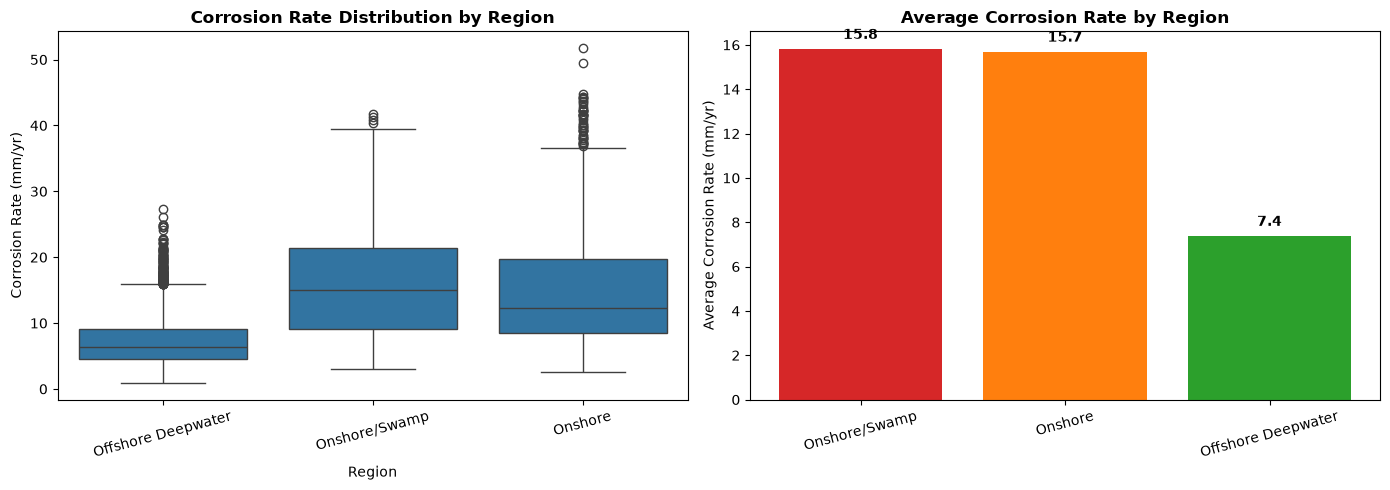

In [4]:
# Insight 1: Corrosion rate by Region
region_corrosion = data.groupby('Region')['CorrosionRate_mmyr'].agg(['mean', 'median', 'std', 'count']).round(2)
print("=== INSIGHT 1: Corrosion Rate by Region ===")
print(region_corrosion)

onshore_swamp_mean = region_corrosion.loc['Onshore/Swamp', 'mean']
offshore_mean = region_corrosion.loc['Offshore Deepwater', 'mean']
onshore_mean = region_corrosion.loc['Onshore', 'mean']

print(f"\nOnshore/Swamp avg corrosion: {onshore_swamp_mean:.2f} mm/yr")
print(f"Onshore avg corrosion: {onshore_mean:.2f} mm/yr")
print(f"Offshore Deepwater avg corrosion: {offshore_mean:.2f} mm/yr")
print(f"\nOnshore/Swamp vs Offshore ratio: {onshore_swamp_mean/offshore_mean:.2f}x")
print(f"Onshore vs Offshore ratio: {onshore_mean/offshore_mean:.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=data, x='Region', y='CorrosionRate_mmyr', ax=axes[0])
axes[0].set_title('Corrosion Rate Distribution by Region', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Corrosion Rate (mm/yr)')
axes[0].tick_params(axis='x', rotation=15)

region_means = data.groupby('Region')['CorrosionRate_mmyr'].mean().sort_values(ascending=False)
bars = axes[1].bar(region_means.index, region_means.values, color=['#d62728', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Average Corrosion Rate by Region', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Corrosion Rate (mm/yr)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, region_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
#plt.savefig('insight1_corrosion_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

=== INSIGHT 2: Anomaly Rate by Region ===
               Region  Total_Readings  Anomalies  Anomaly_Rate_Pct
0  Offshore Deepwater            2373        150              6.32
1             Onshore             796        102             12.81
2       Onshore/Swamp            2418        287             11.87

--- Anomaly Rate by Corridor ---
             Corridor  Total_Readings  Anomalies  Anomaly_Rate_Pct
3           Edo State             796        102             12.81
2         Delta State            1609        199             12.37
4        Rivers State             809         88             10.88
0  Akwa Ibom Offshore             807         54              6.69
1    Bayelsa Offshore            1566         96              6.13


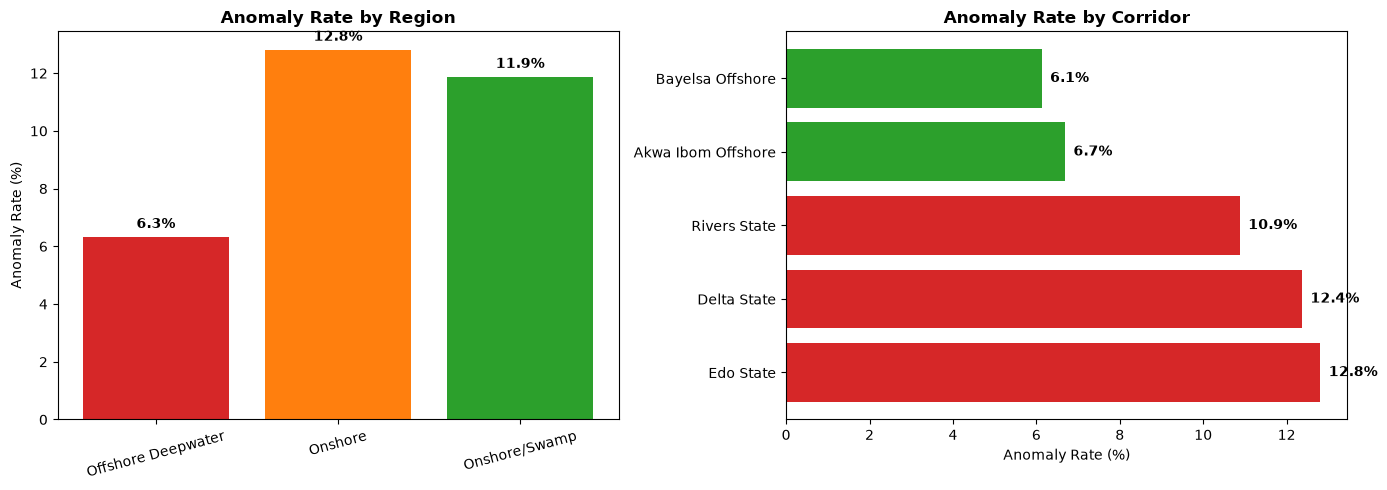

In [5]:
# Insight 2: Anomaly Rate by Region
print("=== INSIGHT 2: Anomaly Rate by Region ===")
anomaly_by_region = data.groupby('Region').agg(
    Total_Readings=('AnomalyFlag', 'count'),
    Anomalies=('AnomalyFlag', 'sum'),
).reset_index()
anomaly_by_region['Anomaly_Rate_Pct'] = (anomaly_by_region['Anomalies'] / anomaly_by_region['Total_Readings'] * 100).round(2)
print(anomaly_by_region)

print("\n--- Anomaly Rate by Corridor ---")
anomaly_by_corridor = data.groupby('Corridor').agg(
    Total_Readings=('AnomalyFlag', 'count'),
    Anomalies=('AnomalyFlag', 'sum'),
).reset_index()
anomaly_by_corridor['Anomaly_Rate_Pct'] = (anomaly_by_corridor['Anomalies'] / anomaly_by_corridor['Total_Readings'] * 100).round(2)
anomaly_by_corridor = anomaly_by_corridor.sort_values('Anomaly_Rate_Pct', ascending=False)
print(anomaly_by_corridor)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars1 = axes[0].bar(anomaly_by_region['Region'], anomaly_by_region['Anomaly_Rate_Pct'], 
                     color=['#d62728', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Anomaly Rate by Region', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Anomaly Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, anomaly_by_region['Anomaly_Rate_Pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

colors = ['#d62728' if r > 10 else '#ff7f0e' if r > 8 else '#2ca02c' for r in anomaly_by_corridor['Anomaly_Rate_Pct']]
bars2 = axes[1].barh(anomaly_by_corridor['Corridor'], anomaly_by_corridor['Anomaly_Rate_Pct'], color=colors)
axes[1].set_title('Anomaly Rate by Corridor', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Anomaly Rate (%)')
for bar, val in zip(bars2, anomaly_by_corridor['Anomaly_Rate_Pct']):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}%', ha='left', va='center', fontweight='bold')
plt.tight_layout()
#plt.savefig('insight2_anomaly_rate.png', dpi=150, bbox_inches='tight')
plt.show()

=== INSIGHT 3: Corrosion Rate by Pipeline Age ===
             mean  median   std  count
Age_Bucket                            
0-5 yrs      6.69    5.93  3.72   1149
5-10 yrs     9.93    8.23  5.72   1845
10-15 yrs   13.18   10.89  7.39   1258
15-20 yrs   19.58   18.44  9.20    779
20+ yrs     19.02   19.04  7.47    546

--- Correlation: PipeAge vs CorrosionRate ---
Pearson correlation: 0.555


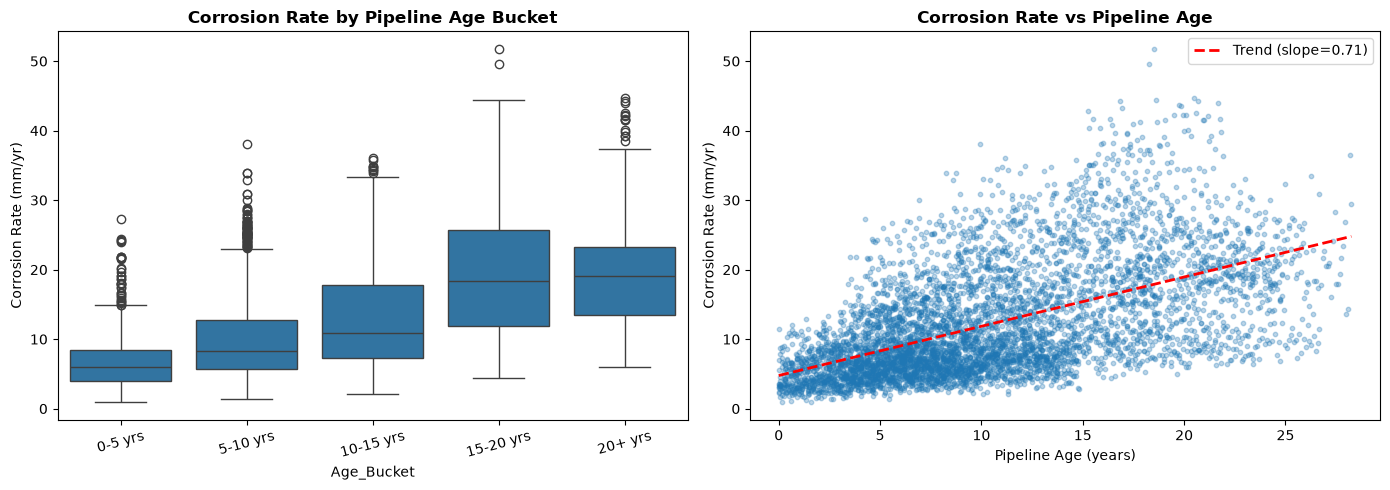

In [6]:
# Insight 3: Corrosion accelerates with pipeline age
data['Age_Bucket'] = pd.cut(data['PipeAge_years'], 
                          bins=[0, 5, 10, 15, 20, 100], 
                          labels=['0-5 yrs', '5-10 yrs', '10-15 yrs', '15-20 yrs', '20+ yrs'])

print("=== INSIGHT 3: Corrosion Rate by Pipeline Age ===")
age_corrosion = data.groupby('Age_Bucket')['CorrosionRate_mmyr'].agg(['mean', 'median', 'std', 'count']).round(2)
print(age_corrosion)

print("\n--- Correlation: PipeAge vs CorrosionRate ---")
correlation = data['PipeAge_years'].corr(data['CorrosionRate_mmyr'])
print(f"Pearson correlation: {correlation:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=data, x='Age_Bucket', y='CorrosionRate_mmyr', ax=axes[0])
axes[0].set_title('Corrosion Rate by Pipeline Age Bucket', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Corrosion Rate (mm/yr)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].scatter(data['PipeAge_years'], data['CorrosionRate_mmyr'], alpha=0.3, s=10)
z = np.polyfit(data['PipeAge_years'], data['CorrosionRate_mmyr'], 1)
p = np.poly1d(z)
axes[1].plot(data['PipeAge_years'].sort_values(), p(data['PipeAge_years'].sort_values()), 
             "r--", linewidth=2, label=f'Trend (slope={z[0]:.2f})')
axes[1].set_title('Corrosion Rate vs Pipeline Age', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pipeline Age (years)')
axes[1].set_ylabel('Corrosion Rate (mm/yr)')
axes[1].legend()
plt.tight_layout()
#plt.savefig("insight3_corrosion_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

=== INSIGHT 4: Third-Party Interference Concentration ===
--- By Field ---
                    FieldName  Total_Readings  Interference_Events
5                        Oben             796                    9
3              Forcados Yokri             799                    6
6         TNP-Export-Corridor             809                    6
4  Forcados-Escravos-Corridor             810                    5
1                       Bonga             803                    2
2                       Egina             807                    2
0                      Agbami             763                    1

--- By Corridor ---
             Corridor  Total_Readings  Interference_Events
2         Delta State            1609                   11
3           Edo State             796                    9
4        Rivers State             809                    6
1    Bayelsa Offshore            1566                    3
0  Akwa Ibom Offshore             807                    2

--- Top 10 Se

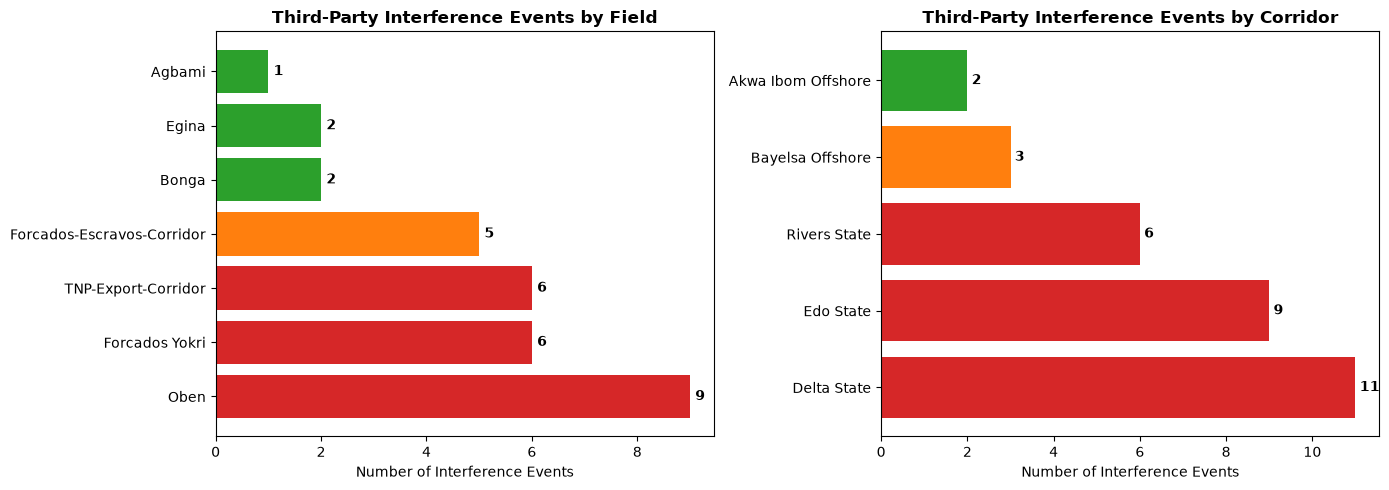

In [7]:
# Insight 4: Third-party interference concentration
print("=== INSIGHT 4: Third-Party Interference Concentration ===")

interference_by_field = data.groupby('FieldName').agg(
    Total_Readings=('ThirdPartyInterferenceEvent', 'count'),
    Interference_Events=('ThirdPartyInterferenceEvent', 'sum'),
).reset_index()
interference_by_field = interference_by_field.sort_values('Interference_Events', ascending=False)
print("--- By Field ---")
print(interference_by_field)

interference_by_corridor = data.groupby('Corridor').agg(
    Total_Readings=('ThirdPartyInterferenceEvent', 'count'),
    Interference_Events=('ThirdPartyInterferenceEvent', 'sum'),
).reset_index()
interference_by_corridor = interference_by_corridor.sort_values('Interference_Events', ascending=False)
print("\n--- By Corridor ---")
print(interference_by_corridor)

interference_by_segment = data.groupby('SegmentID').agg(
    Total_Readings=('ThirdPartyInterferenceEvent', 'count'),
    Interference_Events=('ThirdPartyInterferenceEvent', 'sum'),
).reset_index()
interference_by_segment = interference_by_segment.sort_values('Interference_Events', ascending=False)
print("\n--- Top 10 Segments by Interference Events ---")
print(interference_by_segment.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_fields = interference_by_field.head(8)
bars1 = axes[0].barh(top_fields['FieldName'], top_fields['Interference_Events'], 
                     color=['#d62728' if e > 5 else '#ff7f0e' if e > 2 else '#2ca02c' for e in top_fields['Interference_Events']])
axes[0].set_title('Third-Party Interference Events by Field', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Interference Events')
for bar, val in zip(bars1, top_fields['Interference_Events']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{int(val)}', ha='left', va='center', fontweight='bold')

bars2 = axes[1].barh(interference_by_corridor['Corridor'], interference_by_corridor['Interference_Events'],
                     color=['#d62728' if e > 5 else '#ff7f0e' if e > 2 else '#2ca02c' for e in interference_by_corridor['Interference_Events']])
axes[1].set_title('Third-Party Interference Events by Corridor', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Interference Events')
for bar, val in zip(bars2, interference_by_corridor['Interference_Events']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{int(val)}', ha='left', va='center', fontweight='bold')
plt.tight_layout()
#plt.savefig('insight4_third_party_interference.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# List all column names that contain text/strings
data.select_dtypes(include=['object', 'category']).columns.tolist()


C:\Users\USER\AppData\Local\Temp\ipykernel_29500\2237303248.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include=['object', 'category']).columns.tolist()


['SegmentID',
 'ReadingDate',
 'FieldName',
 'Region',
 'Corridor',
 'MaterialGrade',
 'CoatingType',
 'InstallDate',
 'Status',
 'Age_Bucket']

In [9]:
data['Age_Bucket'].value_counts()

Age_Bucket
5-10 yrs     1845
10-15 yrs    1258
0-5 yrs      1149
15-20 yrs     779
20+ yrs       546
Name: count, dtype: int64

In [10]:
data['FieldName'].value_counts()

FieldName
Forcados-Escravos-Corridor    810
TNP-Export-Corridor           809
Egina                         807
Bonga                         803
Forcados Yokri                799
Oben                          796
Agbami                        763
Name: count, dtype: int64

In [11]:
data['Region'].value_counts()

Region
Onshore/Swamp         2418
Offshore Deepwater    2373
Onshore                796
Name: count, dtype: int64

In [12]:
data['Corridor'].value_counts()

Corridor
Delta State           1609
Bayelsa Offshore      1566
Rivers State           809
Akwa Ibom Offshore     807
Edo State              796
Name: count, dtype: int64

In [13]:
data = pd.get_dummies(data, columns=['Region', 'MaterialGrade', 'CoatingType',], drop_first=True, dtype=int)

In [14]:
data.head()

,SegmentID,ReadingDate,PipeAge_years,Pressure_bar,FlowRate_bpd,Temperature_C,CO2PartialPressure_bar,pH,FlowVelocity_ms,WaterCutPct,...,Status,Age_Bucket,Region_Onshore,Region_Onshore/Swamp,MaterialGrade_API 5L X60,MaterialGrade_API 5L X65,MaterialGrade_API 5L X70,CoatingType_Coal Tar Enamel,CoatingType_FBE (Fusion Bonded Epoxy),CoatingType_None/Bare
0,SEG-0001,2019-01-01,7.25,41.23,8395.6,22.82,4.252,6.04,0.78,38.26,...,In-Service,5-10 yrs,0,0,1,0,0,0,1,0
1,SEG-0001,2019-02-01,7.34,42.02,5364.9,20.35,3.786,5.99,1.20,44.51,...,In-Service,5-10 yrs,0,0,1,0,0,0,1,0
2,SEG-0001,2019-03-01,7.41,58.86,9766.1,24.89,3.747,6.16,1.29,35.58,...,In-Service,5-10 yrs,0,0,1,0,0,0,1,0
3,SEG-0001,2019-04-01,7.50,43.47,9756.9,25.96,4.276,5.79,1.35,36.65,...,In-Service,5-10 yrs,0,0,1,0,0,0,1,0
4,SEG-0001,2019-05-01,7.58,36.89,8049.2,26.50,4.485,6.06,0.90,29.50,...,In-Service,5-10 yrs,0,0,1,0,0,0,1,0


In [15]:
data.describe()

,PipeAge_years,Pressure_bar,FlowRate_bpd,Temperature_C,CO2PartialPressure_bar,pH,FlowVelocity_ms,WaterCutPct,PressureFluctuation_std,VibrationIndex,...,SoilResistivity_ohmcm,ThirdPartyInterferenceExposure,Region_Onshore,Region_Onshore/Swamp,MaterialGrade_API 5L X60,MaterialGrade_API 5L X65,MaterialGrade_API 5L X70,CoatingType_Coal Tar Enamel,CoatingType_FBE (Fusion Bonded Epoxy),CoatingType_None/Bare
count,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,...,3214.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000
mean,10.517806,43.874555,8012.374834,50.750798,3.822049,5.541976,2.258087,45.826168,2.078319,2.123388,...,3919.616677,0.448441,0.142474,0.432790,0.402005,0.215858,0.096116,0.175586,0.273134,0.096474
std,6.238552,8.743872,1514.673718,14.949718,1.632077,0.443420,0.702285,20.767776,1.126128,0.676073,...,1969.130408,0.288684,0.349567,0.495507,0.490347,0.411453,0.294777,0.380502,0.445609,0.295267
min,0.000000,13.250000,1416.300000,20.000000,0.300000,4.360000,0.300000,2.000000,0.000000,0.200000,...,900.400000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.670000,38.060000,7019.150000,39.725000,2.485000,5.180000,1.720000,29.800000,1.350000,1.690000,...,2226.600000,0.120000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.420000,44.050000,8004.900000,48.680000,3.746000,5.550000,2.340000,43.110000,2.030000,2.050000,...,3870.200000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,14.660000,49.770000,8998.750000,59.760000,5.165000,5.920000,2.825000,61.575000,2.700000,2.450000,...,5582.400000,0.750000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,28.250000,79.620000,13435.400000,92.710000,7.626000,6.610000,4.090000,97.000000,11.480000,6.440000,...,7942.800000,0.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:


# 1. Define your threshold value here
threshold = 0.4

# 2. Correlate everything against CorrosionRate_mmyr specifically
target_corr = data.corr(numeric_only=True)["CorrosionRate_mmyr"]

# 3. Drop the target's correlation with itself (always 1.0)
target_corr = target_corr.drop("CorrosionRate_mmyr")

# 4. Filter for absolute correlation above threshold (catches strong negative too)
high_corr_with_target = target_corr[target_corr.abs() > threshold].sort_values(ascending=False)

print(high_corr_with_target)

CumulativeRepairs                 0.683113
Temperature_C                     0.671426
WaterCutPct                       0.586619
PipeAge_years                     0.554590
ThirdPartyInterferenceExposure    0.521699
Name: CorrosionRate_mmyr, dtype: float64


In [ ]:
features = ['CO2PartialPressure_bar', 'pH', 'FlowVelocity_ms', 'Pressure_bar', 'Temperature_C', 
            'WaterCutPct', 'PipeAge_years', 'ThirdPartyInterferenceExposure', 'PressureFluctuation_std', 'VibrationIndex', 
            'NominalWallThickness_mm', 'Diameter_in']

In [24]:
x = data[features]          # DataFrame, not .values
y = data['CorrosionRate_mmyr']   # Series, not .values
groups = data['SegmentID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(x, y, groups=groups))

x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [25]:
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [26]:
#Checking the model's performance metrics
mae  = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
#Print them
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

Mean Absolute Error (MAE): 1.6039212176200337
Mean Squared Error (MSE): 5.581413521625348
Root Mean Squared Error (RMSE): 2.3625015389678263
R-squared (R2): 0.9311508966893862


In [40]:

# --- Settings ---
CRITICAL_PCT = 0.25      # 25% of nominal wall thickness = critical
HORIZON_MONTHS = 6       # flag if breach projected within next 6 months

# --- Pull the full rows (with wall thickness, dates, etc.) for the test set ---
df_test = data.loc[x_test.index].copy()
df_test['PredictedCorrosionRate_mmyr'] = model.predict(x_test)

# --- Project forward using the PREDICTED rate + CURRENT remaining thickness ---
df_test['CriticalThickness_mm'] = CRITICAL_PCT * df_test['NominalWallThickness_mm']
df_test['ProjectedWallLoss_mm'] = df_test['PredictedCorrosionRate_mmyr'] / 12 * HORIZON_MONTHS
df_test['ProjectedRemainingThickness_mm'] = (
    df_test['RemainingWallThickness_mm'] - df_test['ProjectedWallLoss_mm']
)
df_test['RiskFlag'] = (
    df_test['ProjectedRemainingThickness_mm'] <= df_test['CriticalThickness_mm']
).astype(int)

print(f"Flagged at-risk: {df_test['RiskFlag'].sum()} / {len(df_test)} "
      f"({df_test['RiskFlag'].mean()*100:.2f}%)")

# --- Validate PROPERLY: does the flag predict an anomaly in the NEXT N months? ---
# (NOT the same-month AnomalyFlag -- that column already reflects a post-repair reset)
df_test['ReadingDate'] = pd.to_datetime(df_test['ReadingDate'])
df_test = df_test.sort_values(['SegmentID', 'ReadingDate'])

def forward_anomaly(group, horizon=HORIZON_MONTHS):
    flags = group['AnomalyFlag'].values
    out = np.zeros(len(flags), dtype=int)
    for i in range(len(flags)):
        out[i] = int(flags[i+1:i+1+horizon].sum() > 0)
    return pd.Series(out, index=group.index)

df_test['ActualAnomalyWithinHorizon'] = (
    df_test.groupby('SegmentID', group_keys=False).apply(forward_anomaly)
)

prec = precision_score(df_test['ActualAnomalyWithinHorizon'], df_test['RiskFlag'], zero_division=0)
rec = recall_score(df_test['ActualAnomalyWithinHorizon'], df_test['RiskFlag'], zero_division=0)
print(f"Precision: {prec:.3f}  |  Recall: {rec:.3f}")
print(confusion_matrix(df_test['ActualAnomalyWithinHorizon'], df_test['RiskFlag']))

Flagged at-risk: 768 / 1159 (66.26%)
Precision: 0.879  |  Recall: 0.973
[[372  93]
 [ 19 675]]


In [29]:
# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
data['ReadingDate'] = pd.to_datetime(data['ReadingDate'])

# ---------------------------------------------------------------------------
# Use the SAME group split as your corrosion regression model, so both
# models are evaluated on identical held-out segments
# ---------------------------------------------------------------------------
reg_features = ['CO2PartialPressure_bar', 'pH', 'FlowVelocity_ms', 'Pressure_bar', 'Temperature_C',
                'WaterCutPct', 'PipeAge_years', 'ThirdPartyInterferenceExposure', 'PressureFluctuation_std',
                'VibrationIndex', 'NominalWallThickness_mm', 'Diameter_in']

x = data[reg_features]
y = data['CorrosionRate_mmyr']
groups = data['SegmentID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(x, y, groups=groups))

# ---------------------------------------------------------------------------
# Isolation Forest -- trained on SENSOR PATTERN features only
# (deliberately separate from the corrosion-chemistry features above,
# since this model's job is catching sudden anomalies, not slow degradation)
# ---------------------------------------------------------------------------
sensor_features = ['Pressure_bar', 'FlowRate_bpd', 'FlowVelocity_ms',
                    'PressureFluctuation_std', 'VibrationIndex']

x_sensor = data[sensor_features]
x_sensor_train, x_sensor_test = x_sensor.iloc[train_idx], x_sensor.iloc[test_idx]

# contamination = the real observed anomaly rate in training data
contamination_rate = data.iloc[train_idx]['AnomalyFlag'].mean()
print(f"Contamination set to: {contamination_rate:.4f}")

iso = IsolationForest(
    n_estimators=300,
    contamination=contamination_rate,
    random_state=42,
)
iso.fit(x_sensor_train)

# decision_function: higher = more normal. Flip sign so higher = more anomalous.
iso_scores_test = -iso.decision_function(x_sensor_test)
iso_pred_test = (iso.predict(x_sensor_test) == -1).astype(int)  # 1 = flagged anomaly

# ---------------------------------------------------------------------------
# Evaluate against ground truth
# ---------------------------------------------------------------------------
df_test = data.iloc[test_idx].copy()
df_test['IsoAnomalyScore'] = iso_scores_test
df_test['IsoAnomalyFlag'] = iso_pred_test

print(f"\nFlagged: {df_test['IsoAnomalyFlag'].sum()} / {len(df_test)} "
      f"({df_test['IsoAnomalyFlag'].mean()*100:.2f}%)")

for label_col in ['AnomalyFlag', 'ThirdPartyInterferenceEvent']:
    prec = precision_score(df_test[label_col], df_test['IsoAnomalyFlag'], zero_division=0)
    rec = recall_score(df_test[label_col], df_test['IsoAnomalyFlag'], zero_division=0)
    auc = roc_auc_score(df_test[label_col], df_test['IsoAnomalyScore'])
    print(f"  vs {label_col:28s} -> precision={prec:.3f}  recall={rec:.3f}  AUC={auc:.3f}")

Contamination set to: 0.0921

Flagged: 155 / 1159 (13.37%)
  vs AnomalyFlag                  -> precision=0.355  recall=0.420  AUC=0.785
  vs ThirdPartyInterferenceEvent  -> precision=0.045  recall=1.000  AUC=0.997


In [33]:
# ---------------------------------------------------------------------------
# Reload a clean copy just for the columns get_dummies destroyed
# (FieldName, Region) -- your working `data` is now one-hot encoded
# ---------------------------------------------------------------------------
raw_data = pd.read_csv("pipeline_merged_dataset.csv")
raw_data['ReadingDate'] = pd.to_datetime(raw_data['ReadingDate'])

# ---------------------------------------------------------------------------
# Build predictions on the test set using your already-trained model + iso
# ---------------------------------------------------------------------------
df_test = raw_data.iloc[test_idx].copy()
df_test['PredictedCorrosionRate_mmyr'] = model.predict(x_test)
df_test['IsoAnomalyScore'] = -iso.decision_function(x_sensor_test)
df_test['IsoAnomalyFlag'] = (iso.predict(x_sensor_test) == -1).astype(int)

# --- Corrosion threshold flag (tuned: 15% critical, 6-month horizon) ---
CRITICAL_PCT = 0.15
HORIZON_MONTHS = 6
df_test['CriticalThickness_mm'] = CRITICAL_PCT * df_test['NominalWallThickness_mm']
df_test['ProjectedWallLoss_mm'] = df_test['PredictedCorrosionRate_mmyr'] / 12 * HORIZON_MONTHS
df_test['ProjectedRemainingThickness_mm'] = df_test['RemainingWallThickness_mm'] - df_test['ProjectedWallLoss_mm']
df_test['CorrosionRiskFlag'] = (df_test['ProjectedRemainingThickness_mm'] <= df_test['CriticalThickness_mm']).astype(int)

safe_margin = (df_test['RemainingWallThickness_mm'] - df_test['CriticalThickness_mm']).clip(lower=0)
df_test['EstimatedYearsToCritical'] = np.where(
    df_test['PredictedCorrosionRate_mmyr'] > 0.01,
    safe_margin / df_test['PredictedCorrosionRate_mmyr'], np.inf
)

# ---------------------------------------------------------------------------
# Take each segment's most recent reading + assign a combined risk tier
# ---------------------------------------------------------------------------
latest = df_test.sort_values('ReadingDate').groupby('SegmentID', as_index=False).tail(1).copy()

def risk_tier(row):
    if row['CorrosionRiskFlag'] == 1 and row['IsoAnomalyFlag'] == 1:
        return 'CRITICAL'
    elif row['CorrosionRiskFlag'] == 1 or row['IsoAnomalyFlag'] == 1:
        return 'HIGH'
    elif row['EstimatedYearsToCritical'] < 3:
        return 'MEDIUM'
    return 'LOW'

latest['RiskTier'] = latest.apply(risk_tier, axis=1)

risk_matrix = latest[[
    'SegmentID', 'FieldName', 'Region', 'ReadingDate',
    'PredictedCorrosionRate_mmyr', 'RemainingWallThickness_mm', 'NominalWallThickness_mm',
    'EstimatedYearsToCritical', 'CorrosionRiskFlag', 'IsoAnomalyFlag', 'IsoAnomalyScore', 'RiskTier'
]].sort_values(
    ['RiskTier', 'EstimatedYearsToCritical'],
    key=lambda col: col.map({'CRITICAL':0,'HIGH':1,'MEDIUM':2,'LOW':3}) if col.name=='RiskTier' else col
)

risk_matrix.to_csv("segment_risk_matrix.csv", index=False)
print(f"Saved {len(risk_matrix)} segments")
print(risk_matrix['RiskTier'].value_counts())

Saved 13 segments
RiskTier
HIGH      11
MEDIUM     2
Name: count, dtype: int64
